# Домашнее задание №1. Статистический анализ двух бинарных выборок

## Исходные данные

- **Вероятность в группе 1:** p₁ = 0.35
- **Вероятность в группе 2:** p₂ = 0.40
- **Уровень значимости:** α = 0.05
- **Минимальный детектируемый эффект (MDE):** δ = |p₂ - p₁| = 0.05
- **Мощность теста:** 1 - β = 0.8


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
import math

# Исходные данные
p1 = 0.35
p2 = 0.40
alpha = 0.05
power = 0.8  # 1 - beta
beta = 1 - power
delta = abs(p2 - p1)  # MDE

print("=" * 80)
print("ИСХОДНЫЕ ДАННЫЕ")
print("=" * 80)
print(f"Вероятность в группе 1: p₁ = {p1}")
print(f"Вероятность в группе 2: p₂ = {p2}")
print(f"Уровень значимости: α = {alpha}")
print(f"Мощность теста: 1 - β = {power}")
print(f"Минимальный детектируемый эффект: δ = |p₂ - p₁| = {delta}")


ИСХОДНЫЕ ДАННЫЕ
Вероятность в группе 1: p₁ = 0.35
Вероятность в группе 2: p₂ = 0.4
Уровень значимости: α = 0.05
Мощность теста: 1 - β = 0.8
Минимальный детектируемый эффект: δ = |p₂ - p₁| = 0.050000000000000044


## 1. Определение минимального размера выборки

**Цель:** Найти минимальное количество элементов n в каждой выборке, необходимое для детекции MDE с заданной мощностью теста (1 – β = 0.8).

**Формула для расчета:**

$$n = \frac{(z_{1-α/2} \cdot \sqrt{2 \cdot \bar{p} \cdot (1 - \bar{p})} + z_{1-β} \cdot \sqrt{p_1(1-p_1) + p_2(1-p_2)})^2}{δ^2}$$

**где:**
- $\bar{p} = \frac{p_1 + p_2}{2}$ - объединенная пропорция
- $z_{1-α/2}$ - квантиль нормального распределения для двустороннего теста
- $z_{1-β}$ - квантиль нормального распределения для мощности теста


In [ ]:
print("=" * 80)
print("1. МИНИМАЛЬНЫЙ РАЗМЕР ВЫБОРКИ (РАВНЫЕ ГРУППЫ)")
print("=" * 80)

# Объединенная пропорция
p_bar = (p1 + p2) / 2
print(f"\nОбъединенная пропорция: p̄ = (p₁ + p₂) / 2 = ({p1} + {p2}) / 2 = {p_bar:.4f}")

# Квантили нормального распределения
z_alpha_half = norm.ppf(1 - alpha/2)  # z_{1-α/2} для двустороннего теста
z_power = norm.ppf(power)  # z_{1-β}

print(f"\nКвантили нормального распределения:")
print(f"  z_{{1-α/2}} = z_{{0.975}} = {z_alpha_half:.4f}")
print(f"  z_{{1-β}} = z_{{0.8}} = {z_power:.4f}")

# Расчет минимального размера выборки
term1 = z_alpha_half * math.sqrt(2 * p_bar * (1 - p_bar))
term2 = z_power * math.sqrt(p1 * (1 - p1) + p2 * (1 - p2))
numerator = (term1 + term2)**2
denominator = delta**2
n = numerator / denominator

print(f"\nРасчет:")
print(f"  Первое слагаемое: z_{{1-α/2}} * √(2 * p̄ * (1 - p̄)) = {z_alpha_half:.4f} * √(2 * {p_bar:.4f} * {1-p_bar:.4f}) = {term1:.4f}")
print(f"  Второе слагаемое: z_{{1-β}} * √(p₁(1-p₁) + p₂(1-p₂)) = {z_power:.4f} * √({p1*(1-p1):.4f} + {p2*(1-p2):.4f}) = {term2:.4f}")
print(f"  Числитель: ({term1:.4f} + {term2:.4f})² = {numerator:.4f}")
print(f"  Знаменатель: δ² = {delta}² = {denominator:.4f}")
print(f"  n = {numerator:.4f} / {denominator:.4f} = {n:.2f}")

# Округление вверх
n_rounded = math.ceil(n)
print(f"\nОкругление вверх: n = {n_rounded}")
print(f"\nОТВЕТ: n₁ = n₂ = {n_rounded} элементов в каждой группе")


1. МИНИМАЛЬНЫЙ РАЗМЕР ВЫБОРКИ (РАВНЫЕ ГРУППЫ)

Объединенная пропорция: p̄ = (p₁ + p₂) / 2 = (0.35 + 0.4) / 2 = 0.3750

Квантили нормального распределения:
  z_{1-α/2} = z_{0.975} = 1.9600
  z_{1-β} = z_{0.8} = 0.8416

Расчет:
  Первое слагаемое: z_{1-α/2} * √(2 * p̄ * (1 - p̄)) = 1.9600 * √(2 * 0.3750 * 0.6250) = 1.3419
  Второе слагаемое: z_{1-β} * √(p₁(1-p₁) + p₂(1-p₂)) = 0.8416 * √(0.2275 + 0.2400) = 0.5754
  Числитель: (1.3419 + 0.5754)² = 3.6762
  Знаменатель: δ² = 0.050000000000000044² = 0.0025
  n = 3.6762 / 0.0025 = 1470.49

Округление вверх: n = 1471

ОТВЕТ: n₁ = n₂ = 1471 элементов в каждой группе


## 2. Преобразование распределений через ЦПТ

**Цель:** Используя Центральную Предельную Теорему (ЦПТ), преобразовать биномиальные распределения к нормальным.

**Формулы преобразования:**

Для выборки размера n с вероятностью p:
- **Среднее:** μ ≈ p
- **Стандартное отклонение:** σ = √(p(1-p)/n)

**Получаем нормальные распределения:**
- Первая выборка: N(μ₁, σ₁)
- Вторая выборка: N(μ₂, σ₂)


In [ ]:
print("=" * 80)
print("2. ПРЕОБРАЗОВАНИЕ ЧЕРЕЗ ЦПТ")
print("=" * 80)

# Параметры для равных выборок
n_equal = n_rounded
mu1_equal = p1
mu2_equal = p2
sigma1_equal = math.sqrt(p1 * (1 - p1) / n_equal)
sigma2_equal = math.sqrt(p2 * (1 - p2) / n_equal)

print(f"\nРАВНЫЕ ВЫБОРКИ (n={n_equal}):")
print(f"  Группа 1: N(μ={mu1_equal:.4f}, σ={sigma1_equal:.4f})")
print(f"  Группа 2: N(μ={mu2_equal:.4f}, σ={sigma2_equal:.4f})")

# Параметры для неравных выборок (пример: n1 = n/2, n2 = 10*n1)
n1_unequal = math.ceil(n_equal / 2)
n2_unequal = 10 * n1_unequal
mu1_unequal = p1
mu2_unequal = p2
sigma1_unequal = math.sqrt(p1 * (1 - p1) / n1_unequal)
sigma2_unequal = math.sqrt(p2 * (1 - p2) / n2_unequal)

print(f"\nНЕРАВНЫЕ ВЫБОРКИ (n₁={n1_unequal}, n₂={n2_unequal}):")
print(f"  Группа 1: N(μ={mu1_unequal:.4f}, σ={sigma1_unequal:.4f})")
print(f"  Группа 2: N(μ={mu2_unequal:.4f}, σ={sigma2_unequal:.4f})")


2. ПРЕОБРАЗОВАНИЕ ЧЕРЕЗ ЦПТ

РАВНЫЕ ВЫБОРКИ (n=1471):
  Группа 1: N(μ=0.3500, σ=0.0124)
  Группа 2: N(μ=0.4000, σ=0.0128)

НЕРАВНЫЕ ВЫБОРКИ (n₁=736, n₂=7360):
  Группа 1: N(μ=0.3500, σ=0.0176)
  Группа 2: N(μ=0.4000, σ=0.0057)


## 3. Визуализация распределений и ошибок

**Требуется построить два графика:**

**График 1: Двусторонняя альтернатива**
- Распределения обеих выборок
- Критические области для ошибки I рода (α)
- Область ошибки II рода (β)

**График 2: Односторонняя альтернатива (p₁ > p₂)**
- Распределения обеих выборок
- Односторонние критические области
- Соответствующие области ошибок

**Обозначения на графиках:**
- 🔵 Синяя область - Ошибка I рода (вероятность α)
- 🔴 Красная область - Ошибка II рода (вероятность β)
- 📍 Вертикальные линии - Критические значения и средние


3. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ И ОШИБОК

Параметры для визуализации:
  Группа 1: N(μ=0.3500, σ=0.0124)
  Группа 2: N(μ=0.4000, σ=0.0128)

Распределение разности (p₁ - p₂):
  При H₀: N(μ=0, σ=0.0179)
  При H₁: N(μ=-0.0500, σ=0.0178)
  Критические значения (двусторонний): [-0.0350, 0.0350]
  Критическое значение (односторонний): 0.0294


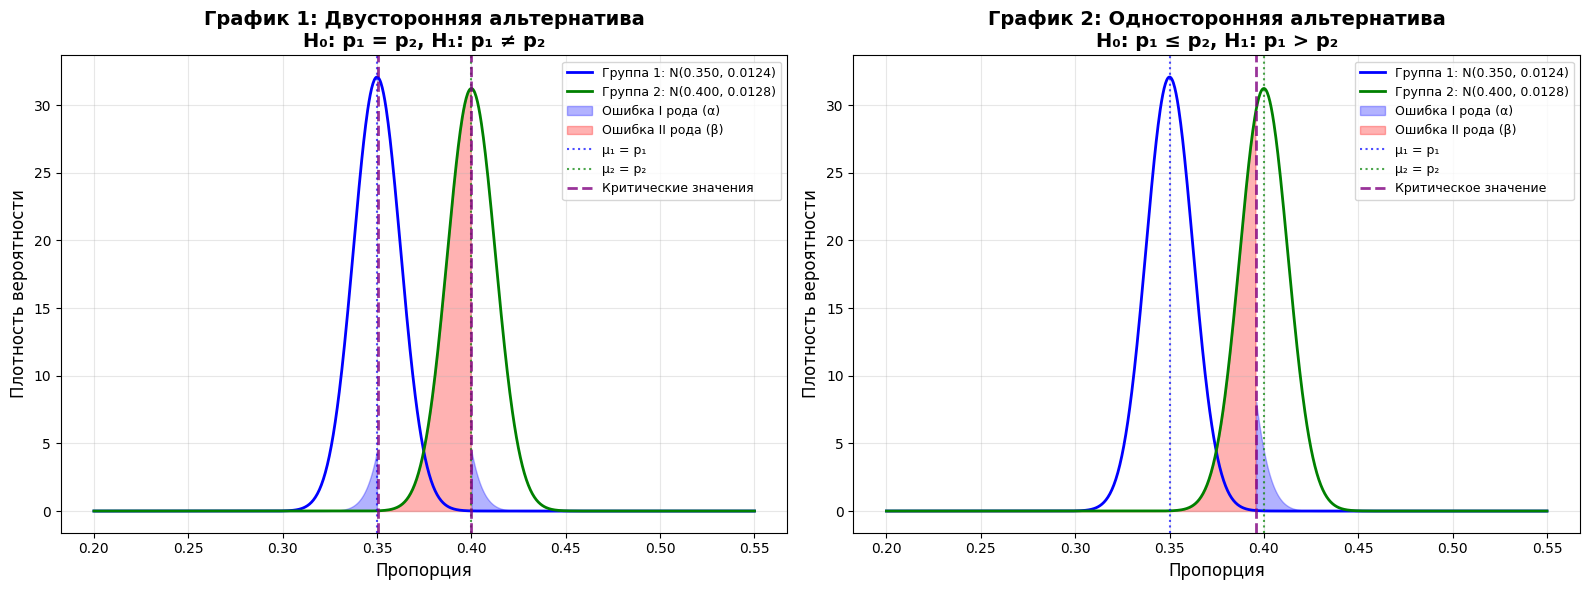


Графики построены:
  🔵 Синяя область - Ошибка I рода (вероятность α)
  🔴 Красная область - Ошибка II рода (вероятность β)
  📍 Вертикальные линии - Критические значения и средние

Примечание: Критические области определены относительно объединенного распределения
при H₀ (p₁ = p₂ = 0.3750)


In [ ]:
print("=" * 80)
print("3. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ И ОШИБОК")
print("=" * 80)

# Используем параметры для равных выборок
mu1, mu2 = mu1_equal, mu2_equal
sigma1, sigma2 = sigma1_equal, sigma2_equal
n = n_equal

# Параметры для распределения разности пропорций
# При H0: p1 = p2, разность имеет среднее 0
p_pooled = (p1 + p2) / 2
se_diff_h0 = math.sqrt(p_pooled * (1 - p_pooled) * (1/n + 1/n))  # Стандартная ошибка разности при H0

# При H1: p1 ≠ p2, разность имеет среднее (p1 - p2) = -0.05
mu_diff_h1 = p1 - p2  # = -0.05
se_diff_h1 = math.sqrt(p1*(1-p1)/n + p2*(1-p2)/n)  # Стандартная ошибка разности при H1

# Критические значения для двустороннего теста (на шкале разности)
z_crit_two = norm.ppf(1 - alpha/2)
critical_lower_diff = -z_crit_two * se_diff_h0  # При H0: разность = 0
critical_upper_diff = z_crit_two * se_diff_h0

# Критическое значение для одностороннего теста (p1 > p2)
# Для одностороннего теста H1: p1 > p2, критическое значение справа
z_crit_one = norm.ppf(1 - alpha)
critical_one_diff = z_crit_one * se_diff_h0

print(f"\nПараметры для визуализации:")
print(f"  Группа 1: N(μ={mu1:.4f}, σ={sigma1:.4f})")
print(f"  Группа 2: N(μ={mu2:.4f}, σ={sigma2:.4f})")
print(f"\nРаспределение разности (p₁ - p₂):")
print(f"  При H₀: N(μ=0, σ={se_diff_h0:.4f})")
print(f"  При H₁: N(μ={mu_diff_h1:.4f}, σ={se_diff_h1:.4f})")
print(f"  Критические значения (двусторонний): [{critical_lower_diff:.4f}, {critical_upper_diff:.4f}]")
print(f"  Критическое значение (односторонний): {critical_one_diff:.4f}")

# Создание графиков
# График 1: Показываем распределения самих пропорций (как в условии)
x = np.linspace(0.2, 0.55, 1000)

# Распределения пропорций
dist1 = norm.pdf(x, mu1, sigma1)
dist2 = norm.pdf(x, mu2, sigma2)

# Для визуализации ошибок используем распределение разности
x_diff = np.linspace(-0.15, 0.1, 1000)
dist_diff_h0 = norm.pdf(x_diff, 0, se_diff_h0)  # При H0
dist_diff_h1 = norm.pdf(x_diff, mu_diff_h1, se_diff_h1)  # При H1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Двусторонняя альтернатива (распределения пропорций)
ax1 = axes[0]
ax1.plot(x, dist1, 'b-', linewidth=2, label=f'Группа 1: N({mu1:.3f}, {sigma1:.4f})')
ax1.plot(x, dist2, 'g-', linewidth=2, label=f'Группа 2: N({mu2:.3f}, {sigma2:.4f})')

# Критические области определяются через разность пропорций
# Преобразуем критические значения разности в критические значения для p2
# При H0: p1 = p2, критическая область для p2 определяется относительно p_pooled
p_pooled = (p1 + p2) / 2
sigma_pooled = math.sqrt(p_pooled * (1 - p_pooled) / n)
critical_lower_p2 = p_pooled - z_crit_two * sigma_pooled
critical_upper_p2 = p_pooled + z_crit_two * sigma_pooled

# Ошибка I рода (синяя) - области, где отклоняем H0, хотя она верна
# Это области вне [critical_lower_p2, critical_upper_p2] под распределением H0
mask_crit_lower = x < critical_lower_p2
mask_crit_upper = x > critical_upper_p2
dist_h0_p2 = norm.pdf(x, p_pooled, sigma_pooled)
ax1.fill_between(x[mask_crit_lower], 0, dist_h0_p2[mask_crit_lower], alpha=0.3, color='blue', label='Ошибка I рода (α)')
ax1.fill_between(x[mask_crit_upper], 0, dist_h0_p2[mask_crit_upper], alpha=0.3, color='blue')

# Ошибка II рода (красная) - область, где не отклоняем H0, хотя она неверна
# Это область между критическими значениями под распределением H1 (p2)
mask_beta = (x >= critical_lower_p2) & (x <= critical_upper_p2)
ax1.fill_between(x[mask_beta], 0, dist2[mask_beta], alpha=0.3, color='red', label='Ошибка II рода (β)')

# Вертикальные линии
ax1.axvline(mu1, color='blue', linestyle=':', linewidth=1.5, alpha=0.7, label='μ₁ = p₁')
ax1.axvline(mu2, color='green', linestyle=':', linewidth=1.5, alpha=0.7, label='μ₂ = p₂')
ax1.axvline(critical_lower_p2, color='purple', linestyle='--', linewidth=2, alpha=0.8, label='Критические значения')
ax1.axvline(critical_upper_p2, color='purple', linestyle='--', linewidth=2, alpha=0.8)

ax1.set_xlabel('Пропорция', fontsize=12)
ax1.set_ylabel('Плотность вероятности', fontsize=12)
ax1.set_title('График 1: Двусторонняя альтернатива\nH₀: p₁ = p₂, H₁: p₁ ≠ p₂', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# График 2: Односторонняя альтернатива (p1 > p2)
ax2 = axes[1]
ax2.plot(x, dist1, 'b-', linewidth=2, label=f'Группа 1: N({mu1:.3f}, {sigma1:.4f})')
ax2.plot(x, dist2, 'g-', linewidth=2, label=f'Группа 2: N({mu2:.3f}, {sigma2:.4f})')

# Критическое значение для одностороннего теста (p1 > p2)
# Критическая область справа от критического значения
critical_one_p2 = p_pooled + z_crit_one * sigma_pooled

# Ошибка I рода (синяя) - область справа от критического значения под H0
mask_crit_one = x > critical_one_p2
ax2.fill_between(x[mask_crit_one], 0, dist_h0_p2[mask_crit_one], alpha=0.3, color='blue', label='Ошибка I рода (α)')

# Ошибка II рода (красная) - область слева от критического значения под H1 (p2)
mask_beta_one = x <= critical_one_p2
ax2.fill_between(x[mask_beta_one], 0, dist2[mask_beta_one], alpha=0.3, color='red', label='Ошибка II рода (β)')

# Вертикальные линии
ax2.axvline(mu1, color='blue', linestyle=':', linewidth=1.5, alpha=0.7, label='μ₁ = p₁')
ax2.axvline(mu2, color='green', linestyle=':', linewidth=1.5, alpha=0.7, label='μ₂ = p₂')
ax2.axvline(critical_one_p2, color='purple', linestyle='--', linewidth=2, alpha=0.8, label='Критическое значение')

ax2.set_xlabel('Пропорция', fontsize=12)
ax2.set_ylabel('Плотность вероятности', fontsize=12)
ax2.set_title('График 2: Односторонняя альтернатива\nH₀: p₁ ≤ p₂, H₁: p₁ > p₂', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nГрафики построены:")
print("  🔵 Синяя область - Ошибка I рода (вероятность α)")
print("  🔴 Красная область - Ошибка II рода (вероятность β)")
print("  📍 Вертикальные линии - Критические значения и средние")
print(f"\nПримечание: Критические области определены относительно объединенного распределения")
print(f"при H₀ (p₁ = p₂ = {p_pooled:.4f})")


## 4. Расчет доверительных интервалов

**Цель:** Построить 95% доверительные интервалы для средних значений обеих выборок.

**Формула доверительного интервала:**

$$CI = \hat{p} \pm z_{1-α/2} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

**где:**
- $\hat{p}$ - выборочная пропорция
- $z_{1-α/2}$ - квантиль стандартного нормального распределения
- $n$ - размер выборки


In [ ]:
print("=" * 80)
print("4. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (уровень доверия 0.95)")
print("=" * 80)

confidence = 0.95
z_ci = norm.ppf(1 - (1 - confidence)/2)

print(f"\nКвантиль для доверительного интервала: z_{{1-α/2}} = z_{{0.975}} = {z_ci:.4f}")

# Равные выборки
print(f"\nРАВНЫЕ ВЫБОРКИ (n={n_equal}):")

se1_equal = math.sqrt(p1 * (1 - p1) / n_equal)
se2_equal = math.sqrt(p2 * (1 - p2) / n_equal)

ci1_lower_equal = p1 - z_ci * se1_equal
ci1_upper_equal = p1 + z_ci * se1_equal
ci1_width_equal = ci1_upper_equal - ci1_lower_equal

ci2_lower_equal = p2 - z_ci * se2_equal
ci2_upper_equal = p2 + z_ci * se2_equal
ci2_width_equal = ci2_upper_equal - ci2_lower_equal

print(f"  Группа 1: [{ci1_lower_equal:.4f}, {ci1_upper_equal:.4f}] (ширина: {ci1_width_equal:.4f})")
print(f"  Группа 2: [{ci2_lower_equal:.4f}, {ci2_upper_equal:.4f}] (ширина: {ci2_width_equal:.4f})")

# Неравные выборки
print(f"\nНЕРАВНЫЕ ВЫБОРКИ (n₁={n1_unequal}, n₂={n2_unequal}):")

se1_unequal = math.sqrt(p1 * (1 - p1) / n1_unequal)
se2_unequal = math.sqrt(p2 * (1 - p2) / n2_unequal)

ci1_lower_unequal = p1 - z_ci * se1_unequal
ci1_upper_unequal = p1 + z_ci * se1_unequal
ci1_width_unequal = ci1_upper_unequal - ci1_lower_unequal

ci2_lower_unequal = p2 - z_ci * se2_unequal
ci2_upper_unequal = p2 + z_ci * se2_unequal
ci2_width_unequal = ci2_upper_unequal - ci2_lower_unequal

print(f"  Группа 1: [{ci1_lower_unequal:.4f}, {ci1_upper_unequal:.4f}] (ширина: {ci1_width_unequal:.4f})")
print(f"  Группа 2: [{ci2_lower_unequal:.4f}, {ci2_upper_unequal:.4f}] (ширина: {ci2_width_unequal:.4f})")


4. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (уровень доверия 0.95)

Квантиль для доверительного интервала: z_{1-α/2} = z_{0.975} = 1.9600

РАВНЫЕ ВЫБОРКИ (n=1471):
  Группа 1: [0.3256, 0.3744] (ширина: 0.0487)
  Группа 2: [0.3750, 0.4250] (ширина: 0.0501)

НЕРАВНЫЕ ВЫБОРКИ (n₁=736, n₂=7360):
  Группа 1: [0.3155, 0.3845] (ширина: 0.0689)
  Группа 2: [0.3888, 0.4112] (ширина: 0.0224)


## Статистические гипотезы

**Для двустороннего теста:**
- H₀: p₁ = p₂
- H₁: p₁ ≠ p₂

**Для одностороннего теста:**
- H₀: p₁ ≤ p₂
- H₁: p₁ > p₂


In [ ]:
print("=" * 80)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("=" * 80)
print(f"\nАНАЛИЗ ДВУХ БИНАРНЫХ ВЫБОРОК")
print(f"\nВходные параметры:")
print(f"  Вероятность в группе 1: {p1}")
print(f"  Вероятность в группе 2: {p2}")
print(f"  Уровень значимости (p-value): {alpha}")
print(f"  Мощность теста: {power}")

print(f"\n1. МИНИМАЛЬНЫЙ РАЗМЕР ВЫБОРКИ (РАВНЫЕ ГРУППЫ):")
print(f"   n₁ = n₂ = {n_rounded} элементов в каждой группе")

print(f"\n2. ПРЕОБРАЗОВАНИЕ ЧЕРЕЗ ЦПТ:")
print(f"   РАВНЫЕ ВЫБОРКИ (n={n_equal}):")
print(f"     Группа 1: N(μ={mu1_equal:.4f}, σ={sigma1_equal:.4f})")
print(f"     Группа 2: N(μ={mu2_equal:.4f}, σ={sigma2_equal:.4f})")
print(f"   НЕРАВНЫЕ ВЫБОРКИ (n₁={n1_unequal}, n₂={n2_unequal}):")
print(f"     Группа 1: N(μ={mu1_unequal:.4f}, σ={sigma1_unequal:.4f})")
print(f"     Группа 2: N(μ={mu2_unequal:.4f}, σ={sigma2_unequal:.4f})")

print(f"\n3. Визуализация:")
print(f"   - График 1: Двусторонняя альтернатива")
print(f"   - График 2: Односторонняя альтернатива")

print(f"\n4. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (уровень доверия 0.95):")
print(f"   РАВНЫЕ ВЫБОРКИ:")
print(f"     Группа 1: [{ci1_lower_equal:.4f}, {ci1_upper_equal:.4f}] (ширина: {ci1_width_equal:.4f})")
print(f"     Группа 2: [{ci2_lower_equal:.4f}, {ci2_upper_equal:.4f}] (ширина: {ci2_width_equal:.4f})")
print(f"   НЕРАВНЫЕ ВЫБОРКИ:")
print(f"     Группа 1: [{ci1_lower_unequal:.4f}, {ci1_upper_unequal:.4f}] (ширина: {ci1_width_unequal:.4f})")
print(f"     Группа 2: [{ci2_lower_unequal:.4f}, {ci2_upper_unequal:.4f}] (ширина: {ci2_width_unequal:.4f})")

print(f"\nСтатистические гипотезы:")
print(f"  Двусторонний тест: H₀: p₁ = p₂, H₁: p₁ ≠ p₂")
print(f"  Односторонний тест: H₀: p₁ ≤ p₂, H₁: p₁ > p₂")


ИТОГОВЫЕ РЕЗУЛЬТАТЫ

АНАЛИЗ ДВУХ БИНАРНЫХ ВЫБОРОК

Входные параметры:
  Вероятность в группе 1: 0.35
  Вероятность в группе 2: 0.4
  Уровень значимости (p-value): 0.05
  Мощность теста: 0.8

1. МИНИМАЛЬНЫЙ РАЗМЕР ВЫБОРКИ (РАВНЫЕ ГРУППЫ):
   n₁ = n₂ = 1471 элементов в каждой группе

2. ПРЕОБРАЗОВАНИЕ ЧЕРЕЗ ЦПТ:
   РАВНЫЕ ВЫБОРКИ (n=1471):
     Группа 1: N(μ=0.3500, σ=0.0124)
     Группа 2: N(μ=0.4000, σ=0.0128)
   НЕРАВНЫЕ ВЫБОРКИ (n₁=736, n₂=7360):
     Группа 1: N(μ=0.3500, σ=0.0176)
     Группа 2: N(μ=0.4000, σ=0.0057)

3. Визуализация:
   - График 1: Двусторонняя альтернатива
   - График 2: Односторонняя альтернатива

4. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (уровень доверия 0.95):
   РАВНЫЕ ВЫБОРКИ:
     Группа 1: [0.3256, 0.3744] (ширина: 0.0487)
     Группа 2: [0.3750, 0.4250] (ширина: 0.0501)
   НЕРАВНЫЕ ВЫБОРКИ:
     Группа 1: [0.3155, 0.3845] (ширина: 0.0689)
     Группа 2: [0.3888, 0.4112] (ширина: 0.0224)

Статистические гипотезы:
  Двусторонний тест: H₀: p₁ = p₂, H₁: p₁ ≠ p₂
  Односторон